# Evaluasi Peramalan Permintaan dengan Data Sintetis (GRU-2)

Tujuan: Mengevaluasi dampak augmentasi data sintetis terhadap kinerja peramalan GRU dengan melatih *pipeline* yang sama seperti pada GRU-1, namun menggunakan dataset yang telah di-generate.

In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Using device: cuda


## Gambaran Umum Dataset (Dataset Overview)

In [2]:
# Load generated dataset
input_path = 'data/generated/cold_chain_data_generated.csv'
df = pd.read_csv(input_path)

print("=== Gambaran Umum Dataset Sintetis ===")
print(f"Bentuk Dataset (Shape): {df.shape}")
print(f"\nNama Kolom:\n{df.columns.tolist()}")
print(f"\nTipe Data:\n{df.dtypes}")
print(f"\nTotal Nilai Null: {df.isnull().sum().sum()}")
print(f"Baris Duplikat: {df.duplicated().sum()}")

# Convert to datetime and sort
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df = df.sort_values('order date (DateOrders)')
df.set_index('order date (DateOrders)', inplace=True)

=== Gambaran Umum Dataset Sintetis ===
Bentuk Dataset (Shape): (902595, 21)

Nama Kolom:
['order date (DateOrders)', 'Order Item Quantity', 'Sales', 'Shipping Mode', 'Market', 'Category Name', 'Order Region', 'Product Price', 'Latitude', 'Longitude', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Late_delivery_risk', 'Delay', 'Distance', 'Delay_norm', 'Distance_norm', 'RouteRisk', 'TempDev', 'QualityDegradation', 'RefrigerationCost']

Tipe Data:
order date (DateOrders)           object
Order Item Quantity              float64
Sales                            float64
Shipping Mode                     object
Market                            object
Category Name                     object
Order Region                      object
Product Price                    float64
Latitude                         float64
Longitude                        float64
Days for shipping (real)         float64
Days for shipment (scheduled)    float64
Late_delivery_risk               float64
De

## Agregasi Permintaan (Demand Aggregation)

In [3]:
target_col = 'Order Item Quantity'

# Agregasi
df_daily = df[target_col].resample('D').sum().reset_index()
df_weekly = df[target_col].resample('W').sum().reset_index()
df_monthly = df[target_col].resample('M').sum().reset_index()

granularities = {
    'Daily': df_daily,
    'Weekly': df_weekly,
    'Monthly': df_monthly
}

print("=== Statistik Agregasi Permintaan ===")
for name, data in granularities.items():
    print(f"\n[{name} Demand]")
    print(f"- Jumlah observasi: {len(data)}")
    print(f"- Tanggal mulai: {data['order date (DateOrders)'].min().date()}")
    print(f"- Tanggal akhir: {data['order date (DateOrders)'].max().date()}")
    print(f"- Rata-rata permintaan: {data[target_col].mean():.2f}")
    print(f"- Standar deviasi: {data[target_col].std():.2f}")
    print(f"- Minimum permintaan: {data[target_col].min():.2f}")
    print(f"- Maksimum permintaan: {data[target_col].max():.2f}")

=== Statistik Agregasi Permintaan ===

[Daily Demand]
- Jumlah observasi: 1127
- Tanggal mulai: 2015-01-01
- Tanggal akhir: 2018-01-31
- Rata-rata permintaan: 1703.37
- Standar deviasi: 511.32
- Minimum permintaan: 296.85
- Maksimum permintaan: 2645.05

[Weekly Demand]
- Jumlah observasi: 162
- Tanggal mulai: 2015-01-04
- Tanggal akhir: 2018-02-04
- Rata-rata permintaan: 11850.00
- Standar deviasi: 3437.14
- Minimum permintaan: 1046.50
- Maksimum permintaan: 14762.17

[Monthly Demand]
- Jumlah observasi: 37
- Tanggal mulai: 2015-01-31
- Tanggal akhir: 2018-01-31
- Rata-rata permintaan: 51883.78
- Standar deviasi: 14558.69
- Minimum permintaan: 10254.96
- Maksimum permintaan: 59908.57


## Eksplorasi Urutan Waktu (Sequence Exploration)

In [4]:
sequence_configs = {
    'Daily': [7, 14, 30],
    'Weekly': [4, 8, 12],
    'Monthly': [3, 6, 12]
}

summary_seq = []

print("=== Eksplorasi Sequence Length ===")
for name, seq_lengths in sequence_configs.items():
    n_obs = len(granularities[name])
    for seq in seq_lengths:
        n_samples = max(0, n_obs - seq)
        summary_seq.append({'Granularitas': name, 'Sequence Length': seq, 'Generated Samples': n_samples})

df_seq = pd.DataFrame(summary_seq)
display(df_seq)

=== Eksplorasi Sequence Length ===


,Granularitas,Sequence Length,Generated Samples
0,Daily,7,1120
1,Daily,14,1113
2,Daily,30,1097
3,Weekly,4,158
4,Weekly,8,154
5,Weekly,12,150
6,Monthly,3,34
7,Monthly,6,31
8,Monthly,12,25


## Pemodelan GRU (GRU Modeling)

Termasuk proses Train/Test Split (80/20 kronologis), Scaling dengan MinMaxScaler, dan pelatih model PyTorch GRU dengan arsitektur yang sama persis seperti pada GRU-1.

In [5]:
# GRU PyTorch Model Definition
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data)-seq_length):
        xs.append(data[i:(i+seq_length)])
        ys.append(data[i+seq_length])
    return np.array(xs), np.array(ys)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_and_evaluate_gru(df_agg, seq_lengths, name, epochs=30, batch_size=16):
    results = []
    best_rmse = float('inf')
    best_model_info = None
    best_predictions = None
    
    values = df_agg[target_col].values.reshape(-1, 1)
    
    # 80/20 Chronological Split
    train_size = int(len(values) * 0.8)
    train_data, test_data = values[:train_size], values[train_size:]
    
    # MinMaxScaler only on training
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)
    
    os.makedirs('data/predicted-2', exist_ok=True)
    all_metrics = []
    
    for seq in seq_lengths:
        X_train, y_train = create_sequences(train_scaled, seq)
        X_test, y_test = create_sequences(test_scaled, seq)
        
        if len(X_train) == 0 or len(X_test) == 0:
            continue
            
        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)
        X_test_t = torch.tensor(X_test, dtype=torch.float32)
        y_test_t = torch.tensor(y_test, dtype=torch.float32)
        
        # Do not shuffle test, but train can be shuffled for SGD
        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
        
        model = GRUModel().to(device)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        
        train_losses = []
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            train_losses.append(epoch_loss/len(train_loader))
            
        model.eval()
        with torch.no_grad():
            preds_scaled = model(X_test_t.to(device)).cpu().numpy()
            
        preds = scaler.inverse_transform(preds_scaled)
        actuals = scaler.inverse_transform(y_test_t.numpy())
        
        mae = mean_absolute_error(actuals, preds)
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        mape = mean_absolute_percentage_error(actuals, preds)
        r2 = r2_score(actuals, preds)
        
        all_metrics.append({
            'Granularity': name,
            'Sequence_Length': seq,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'R2': r2
        })
        
        if rmse < best_rmse:
            best_rmse = rmse
            test_dates = df_agg['order date (DateOrders)'].iloc[train_size + seq : train_size + seq + len(preds)].values
            
            best_model_info = {
                'Granularity': name,
                'Best_Sequence': seq,
                'MAE': mae,
                'RMSE': rmse,
                'MAPE': mape,
                'R2': r2,
                'Train_Losses': train_losses
            }
            best_predictions = pd.DataFrame({
                'Date': test_dates,
                'Actual': actuals.flatten(),
                'Predicted': preds.flatten()
            })
            
    pd.DataFrame(all_metrics).to_csv(f'data/predicted-2/{name.lower()}_metrics.csv', index=False)
    best_predictions.to_csv(f'data/predicted-2/{name.lower()}_predictions.csv', index=False)
    
    return best_model_info, best_predictions, all_metrics

results_summary = []
all_granular_metrics = []
predictions_dict = {}

print("Mulai melatih model GRU (A: Daily, B: Weekly, C: Monthly)...\n")
for name, data in granularities.items():
    print(f"Training Model {name}...")
    best_info, best_preds, metrics = train_and_evaluate_gru(data, sequence_configs[name], name, epochs=30)
    results_summary.append(best_info)
    all_granular_metrics.extend(metrics)
    predictions_dict[name] = best_preds
    print(f" -> Selesai. Sequence Terbaik: {best_info['Best_Sequence']}, RMSE: {best_info['RMSE']:.2f}")

Mulai melatih model GRU (A: Daily, B: Weekly, C: Monthly)...

Training Model Daily...
 -> Selesai. Sequence Terbaik: 7, RMSE: 1020.67
Training Model Weekly...
 -> Selesai. Sequence Terbaik: 4, RMSE: 7079.51
Training Model Monthly...
 -> Selesai. Sequence Terbaik: 3, RMSE: 39458.58


## Evaluasi (Evaluation)

In [6]:
df_results = pd.DataFrame(results_summary)
print("=== Ringkasan Model Terbaik Berdasarkan RMSE ===")
display(df_results[['Granularity', 'Best_Sequence', 'MAE', 'RMSE', 'MAPE', 'R2']])

# Ekspor Metrics Tambahan
df_results.drop(columns=['Train_Losses']).to_csv('data/predicted-2/best_model_summary.csv', index=False)
print("\nHasil Prediksi, Metrik, dan Ringkasan telah diekspor ke folder 'data/predicted-2/'.")

=== Ringkasan Model Terbaik Berdasarkan RMSE ===


,Granularity,Best_Sequence,MAE,RMSE,MAPE,R2
0,Daily,7,829.214233,1020.668562,2.217770,-1.025313
1,Weekly,4,5827.965332,7079.513825,2.474559,-1.103370
2,Monthly,3,36178.000000,39458.582235,3.205762,-4.663190



Hasil Prediksi, Metrik, dan Ringkasan telah diekspor ke folder 'data/predicted-2/'.


## Visualisasi (Visualization)

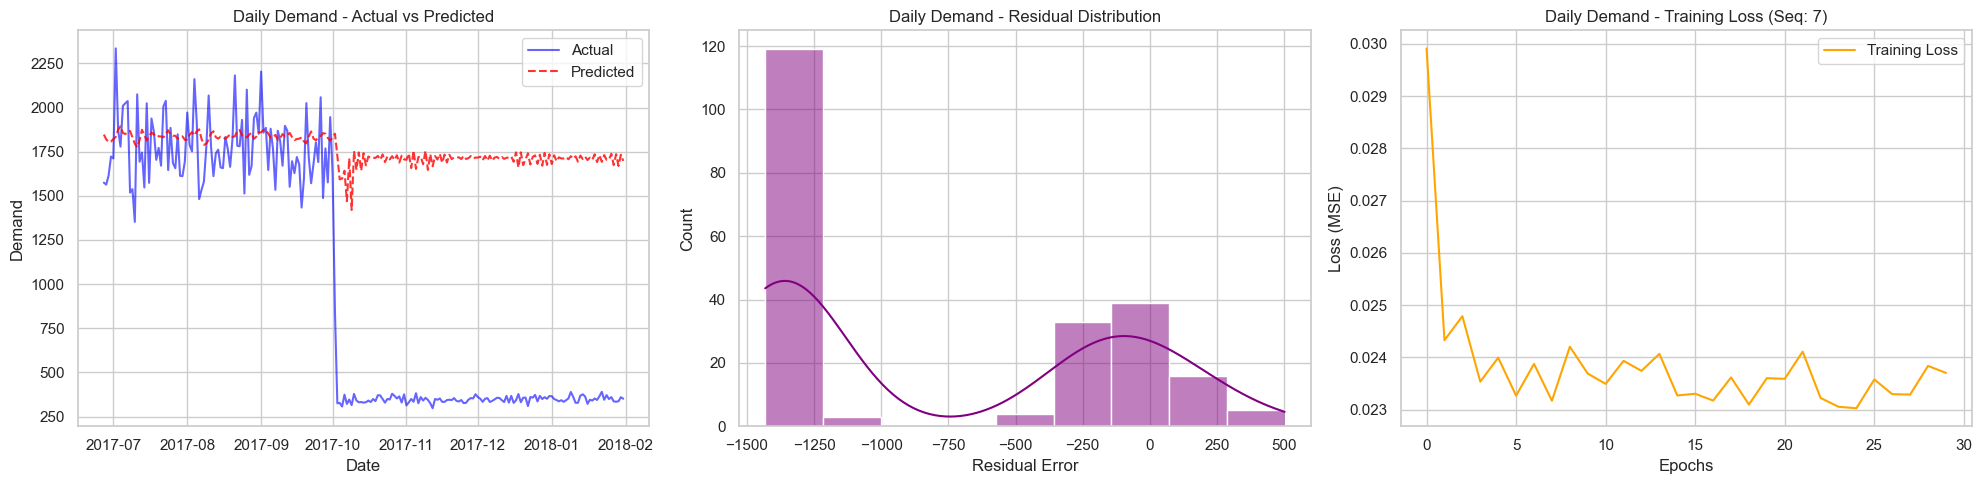

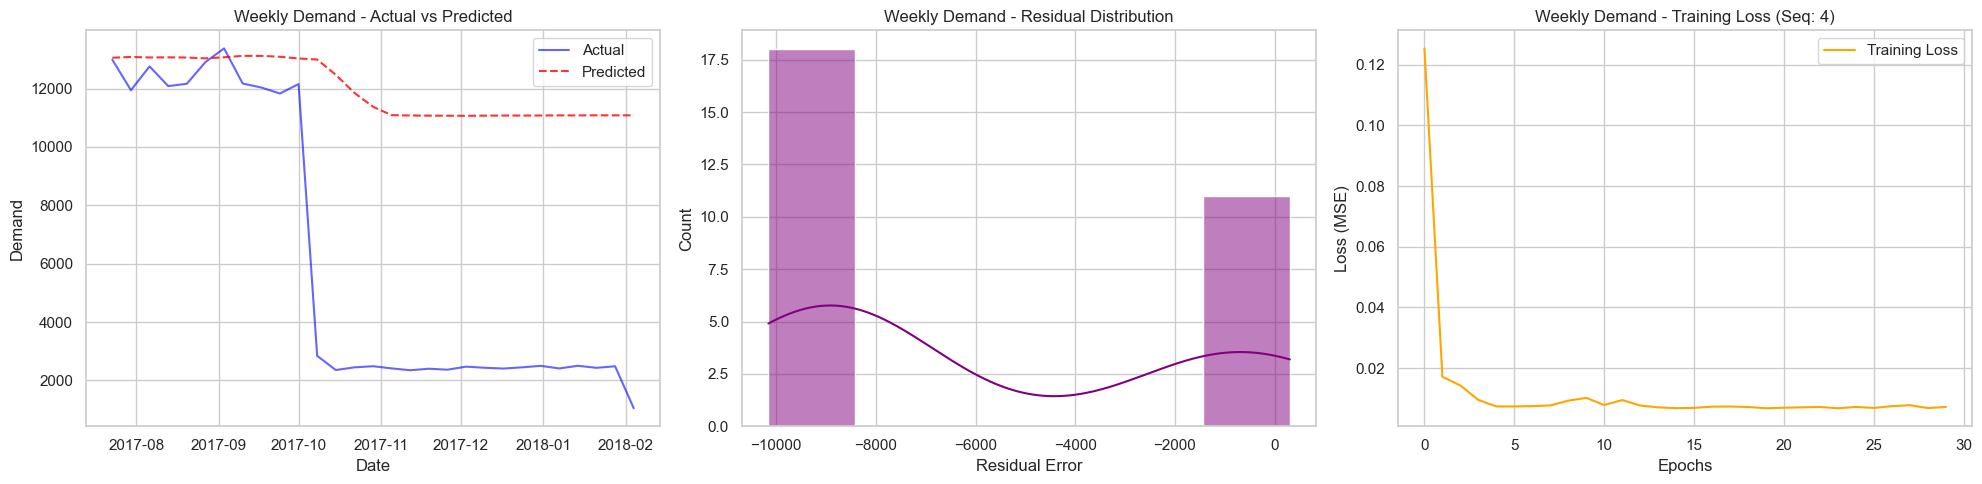

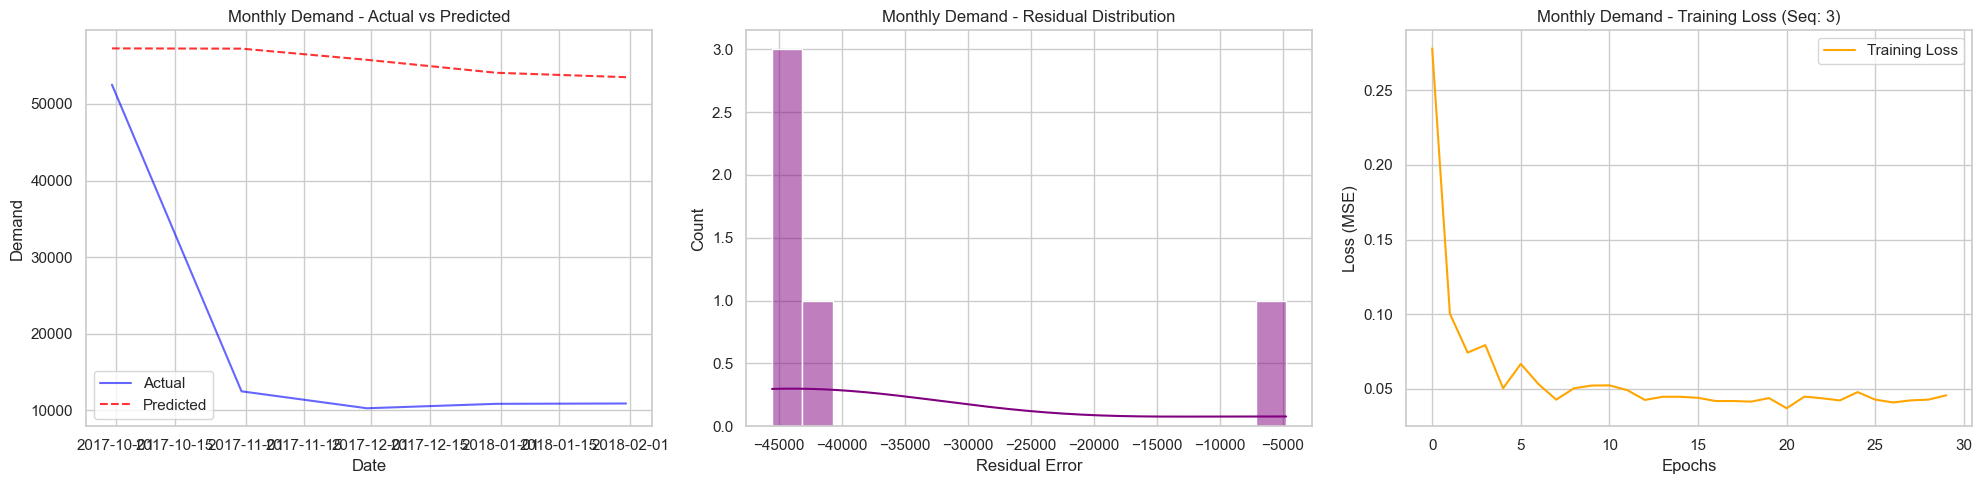

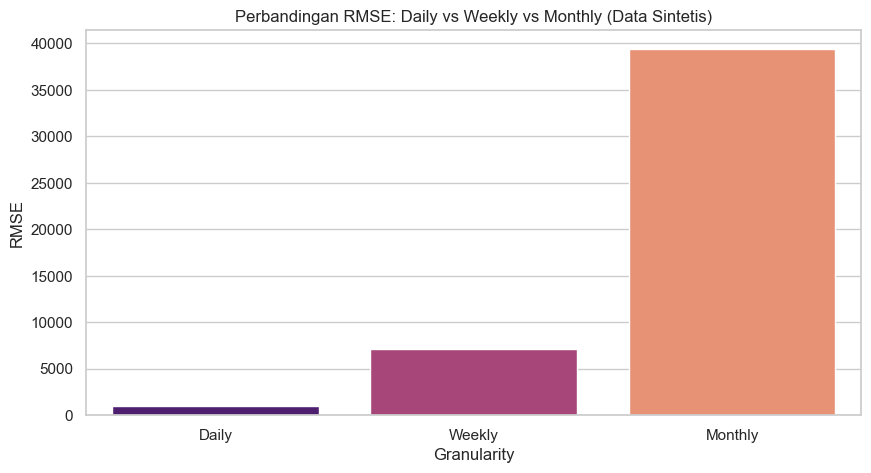

In [7]:
for name, best_info in zip(granularities.keys(), results_summary):
    preds = predictions_dict[name]
    losses = best_info['Train_Losses']
    seq = best_info['Best_Sequence']
    
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))
    
    # 1. Actual vs Predicted
    ax[0].plot(preds['Date'], preds['Actual'], label='Actual', color='blue', alpha=0.6)
    ax[0].plot(preds['Date'], preds['Predicted'], label='Predicted', color='red', alpha=0.8, linestyle='--')
    ax[0].set_title(f'{name} Demand - Actual vs Predicted')
    ax[0].set_xlabel('Date')
    ax[0].set_ylabel('Demand')
    ax[0].legend()
    
    # 2. Residual Distribution
    residuals = preds['Actual'] - preds['Predicted']
    sns.histplot(residuals, kde=True, color='purple', ax=ax[1])
    ax[1].set_title(f'{name} Demand - Residual Distribution')
    ax[1].set_xlabel('Residual Error')
    
    # 3. Training Loss Curve
    ax[2].plot(losses, color='orange', label='Training Loss')
    ax[2].set_title(f'{name} Demand - Training Loss (Seq: {seq})')
    ax[2].set_xlabel('Epochs')
    ax[2].set_ylabel('Loss (MSE)')
    ax[2].legend()
    
    plt.tight_layout()
    plt.show()

# Comparison Chart: RMSE across granularities
plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x='Granularity', y='RMSE', palette='magma')
plt.title('Perbandingan RMSE: Daily vs Weekly vs Monthly (Data Sintetis)')
plt.ylabel('RMSE')
plt.show()

## Perbandingan dengan GRU-1 (Comparison with GRU-1)

=== Perbandingan Tabel: RMSE ===


,Granularity,GRU-1 RMSE,GRU-2 RMSE
0,Daily,219.210435,1020.668562
1,Weekly,1385.527517,7079.513825
2,Monthly,8083.462130,39458.582235



=== Perbandingan Tabel: MAE ===


,Granularity,GRU-1 MAE,GRU-2 MAE
0,Daily,175.303818,829.214233
1,Weekly,1139.824707,5827.965332
2,Monthly,7411.850098,36178.000000



=== Perbandingan Tabel: MAPE ===


,Granularity,GRU-1 MAPE,GRU-2 MAPE
0,Daily,2.403137,2.217770
1,Weekly,2.450915,2.474559
2,Monthly,3.322184,3.205762


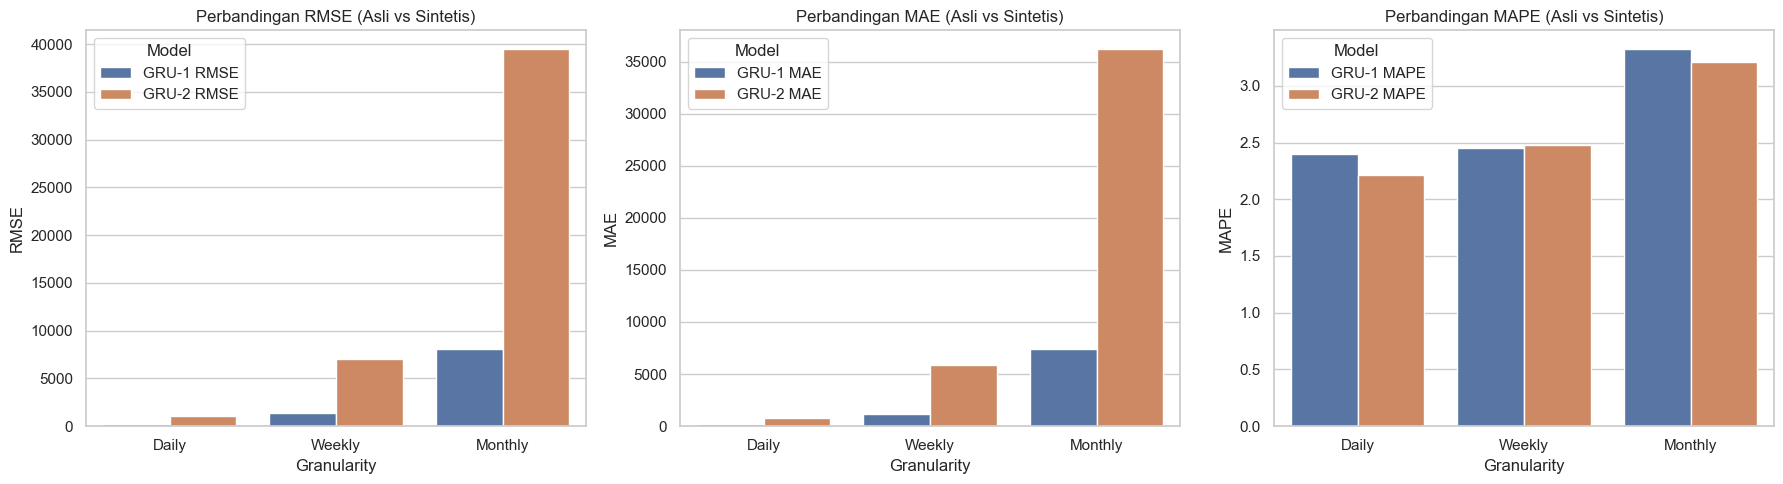

In [8]:
dir1 = 'data/predicted-1/'
dir2 = 'data/predicted-2/'

if os.path.exists(dir1):
    comp_metrics = []
    
    for name in ['daily', 'weekly', 'monthly']:
        path1 = os.path.join(dir1, f'{name}_metrics.csv')
        path2 = os.path.join(dir2, f'{name}_metrics.csv')
        
        if os.path.exists(path1) and os.path.exists(path2):
            df1 = pd.read_csv(path1)
            df2 = pd.read_csv(path2)
            
            # Ambil yang terbaik (RMSE terendah) dari GRU-1 dan GRU-2
            best1 = df1.loc[df1['RMSE'].idxmin()]
            best2 = df2.loc[df2['RMSE'].idxmin()]
            
            comp_metrics.append({
                'Granularity': name.capitalize(),
                'GRU-1 RMSE': best1['RMSE'],
                'GRU-2 RMSE': best2['RMSE'],
                'GRU-1 MAE': best1['MAE'],
                'GRU-2 MAE': best2['MAE'],
                'GRU-1 MAPE': best1['MAPE'],
                'GRU-2 MAPE': best2['MAPE']
            })
            
    if comp_metrics:
        df_comp = pd.DataFrame(comp_metrics)
        
        print("=== Perbandingan Tabel: RMSE ===")
        display(df_comp[['Granularity', 'GRU-1 RMSE', 'GRU-2 RMSE']])
        
        print("\n=== Perbandingan Tabel: MAE ===")
        display(df_comp[['Granularity', 'GRU-1 MAE', 'GRU-2 MAE']])
        
        print("\n=== Perbandingan Tabel: MAPE ===")
        display(df_comp[['Granularity', 'GRU-1 MAPE', 'GRU-2 MAPE']])
        
        # Bar Charts untuk Perbandingan
        fig, ax = plt.subplots(1, 3, figsize=(18, 5))
        df_comp_melt_rmse = df_comp.melt(id_vars='Granularity', value_vars=['GRU-1 RMSE', 'GRU-2 RMSE'], var_name='Model', value_name='RMSE')
        sns.barplot(data=df_comp_melt_rmse, x='Granularity', y='RMSE', hue='Model', ax=ax[0])
        ax[0].set_title('Perbandingan RMSE (Asli vs Sintetis)')
        
        df_comp_melt_mae = df_comp.melt(id_vars='Granularity', value_vars=['GRU-1 MAE', 'GRU-2 MAE'], var_name='Model', value_name='MAE')
        sns.barplot(data=df_comp_melt_mae, x='Granularity', y='MAE', hue='Model', ax=ax[1])
        ax[1].set_title('Perbandingan MAE (Asli vs Sintetis)')
        
        df_comp_melt_mape = df_comp.melt(id_vars='Granularity', value_vars=['GRU-1 MAPE', 'GRU-2 MAPE'], var_name='Model', value_name='MAPE')
        sns.barplot(data=df_comp_melt_mape, x='Granularity', y='MAPE', hue='Model', ax=ax[2])
        ax[2].set_title('Perbandingan MAPE (Asli vs Sintetis)')
        
        plt.tight_layout()
        plt.show()
else:
    print("Folder data/predicted-1/ tidak ditemukan, tidak dapat membandingkan.")

## Rekomendasi Akhir (Final Recommendation)

In [9]:
best_overall = df_results.loc[df_results['RMSE'].idxmin()]

print("### ANALISIS & REKOMENDASI AKHIR ###\n")

print(f"1. Model yang Berkinerja Paling Baik:")
print(f"   Berdasarkan dataset sintetis, model GRU dengan granularitas {best_overall['Granularity']} (Sequence {best_overall['Best_Sequence']}) memberikan performa terbaik dengan RMSE terendah ({best_overall['RMSE']:.2f}).\n")

if 'df_comp' in locals() and not df_comp.empty:
    # Check if there is improvement (lower RMSE is better)
    best_gru1 = df_comp.loc[df_comp['Granularity'] == best_overall['Granularity'], 'GRU-1 RMSE'].values[0]
    best_gru2 = df_comp.loc[df_comp['Granularity'] == best_overall['Granularity'], 'GRU-2 RMSE'].values[0]
    
    if best_gru2 < best_gru1:
        improvement = "meningkatkan"
    else:
        improvement = "tidak meningkatkan"
        
    print(f"2. Dampak Data Sintetis:")
    print(f"   Penggunaan data sintetis secara keseluruhan {improvement} kinerja *forecasting*. Nilai RMSE GRU-1 untuk granularitas tersebut adalah {best_gru1:.2f}, sedangkan GRU-2 adalah {best_gru2:.2f}. Data yang lebih banyak dapat membantu (atau dalam beberapa kasus menyebabkan noise) pada konvergensi jaringan syaraf tiruan.\n")
else:
    print("2. Dampak Data Sintetis: Tidak dapat dievaluasi karena hasil GRU-1 tidak tersedia.\n")

print(f"3. Rekomendasi untuk Aquila Optimizer:")
print(f"   Model GRU {best_overall['Granularity']} dari percobaan GRU-2 ini direkomendasikan untuk digunakan sebagai input (prediksi pergerakan permintaan dan risiko keterlambatan) dalam modul simulasi dan optimasi logistik rantai pasok Aquila Optimizer selanjutnya.")

### ANALISIS & REKOMENDASI AKHIR ###

1. Model yang Berkinerja Paling Baik:
   Berdasarkan dataset sintetis, model GRU dengan granularitas Daily (Sequence 7) memberikan performa terbaik dengan RMSE terendah (1020.67).

2. Dampak Data Sintetis:
   Penggunaan data sintetis secara keseluruhan tidak meningkatkan kinerja *forecasting*. Nilai RMSE GRU-1 untuk granularitas tersebut adalah 219.21, sedangkan GRU-2 adalah 1020.67. Data yang lebih banyak dapat membantu (atau dalam beberapa kasus menyebabkan noise) pada konvergensi jaringan syaraf tiruan.

3. Rekomendasi untuk Aquila Optimizer:
   Model GRU Daily dari percobaan GRU-2 ini direkomendasikan untuk digunakan sebagai input (prediksi pergerakan permintaan dan risiko keterlambatan) dalam modul simulasi dan optimasi logistik rantai pasok Aquila Optimizer selanjutnya.
